# **Importing Dependencies**

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# **Loading dataset**

In [21]:
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')  # We'll use test as validation
val_dir = os.path.join(base_dir, 'val')   # Small validation set

# **Parameters**

In [22]:
img_size = 224  # VGG16 default size
batch_size = 32
epochs = 50

# **Data Augmentation**

In [23]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='constant',
    cval=0,
    brightness_range=[0.9, 1.1],
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [24]:
# Training data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation data (from training split)
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.


In [25]:
# Test data
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


# **MobileNetV2 pre-trained model**

In [26]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

base_model.trainable = False

# Model architecture
x = base_model.output
x = Flatten()(x)
# x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x) 
# x = Dropout(0.4)(x) 
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

optimizer = Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# **Callbacks**

In [27]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# **Model Training**

In [28]:
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/50
139/139 [==============================] - 104s 722ms/step - loss: 0.3742 - accuracy: 0.8331 - val_loss: 0.2088 - val_accuracy: 0.9156 - lr: 1.0000e-05
Epoch 2/50
139/139 [==============================] - 97s 698ms/step - loss: 0.2236 - accuracy: 0.9118 - val_loss: 0.1689 - val_accuracy: 0.9297 - lr: 1.0000e-05
Epoch 3/50
139/139 [==============================] - 100s 720ms/step - loss: 0.1931 - accuracy: 0.9265 - val_loss: 0.1475 - val_accuracy: 0.9425 - lr: 1.0000e-05
Epoch 4/50
139/139 [==============================] - 96s 688ms/step - loss: 0.1682 - accuracy: 0.9348 - val_loss: 0.1422 - val_accuracy: 0.9399 - lr: 1.0000e-05
Epoch 5/50
139/139 [==============================] - 96s 688ms/step - loss: 0.1463 - accuracy: 0.9452 - val_loss: 0.1236 - val_accuracy: 0.9425 - lr: 1.0000e-05
Epoch 6/50
139/139 [==============================] - 97s 698ms/step - loss: 0.1438 - accuracy: 0.9438 - val_loss: 0.1161 - val_accuracy: 0.9552 - lr: 1.0000e-05
Epoch 7/50
139/139 [======

# **Evaluate on test set**

In [29]:
print("\nEvaluating on Test Set:")
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")



Evaluating on Test Set:
20/20 [==============================] - 8s 389ms/step - loss: 0.2386 - accuracy: 0.9151

Test Accuracy: 0.9151


# **Classification Report**

In [30]:
y_true = test_gen.classes
y_pred = (model.predict(test_gen) > 0.5).astype("int32")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

20/20 [==============================] - 6s 228ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.86      0.88       234
   PNEUMONIA       0.92      0.95      0.93       390

    accuracy                           0.92       624
   macro avg       0.91      0.90      0.91       624
weighted avg       0.91      0.92      0.91       624



# **ROC Curve**


20/20 [==============================] - 5s 226ms/step


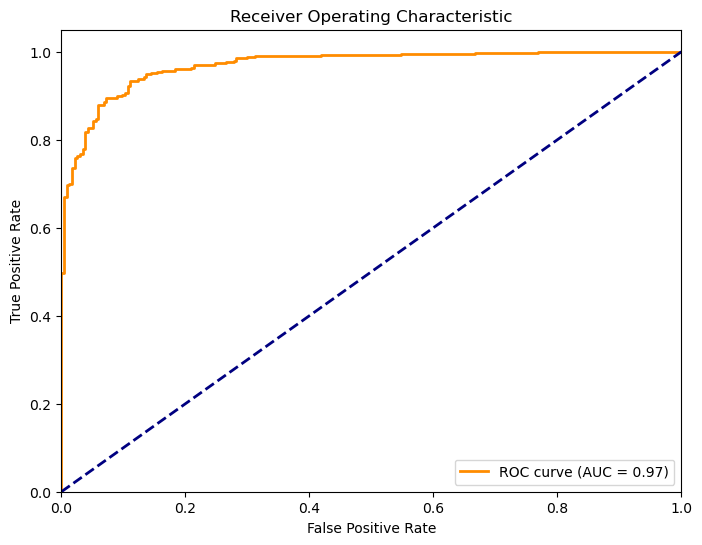

In [31]:
from sklearn.metrics import roc_curve, auc

y_pred_probs = model.predict(test_gen)
fpr, tpr, thresholds = roc_curve(test_gen.classes, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# **Confusion matrix**

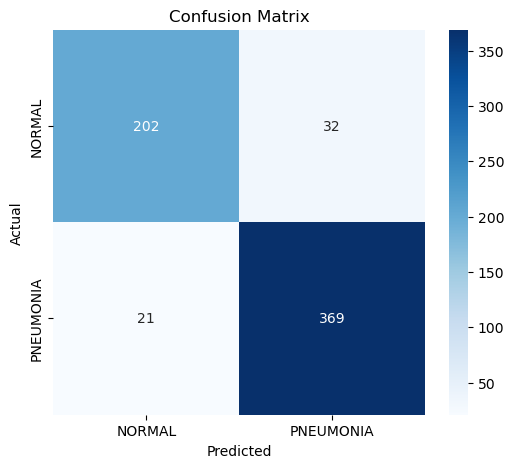

In [32]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'], 
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Plot training history**

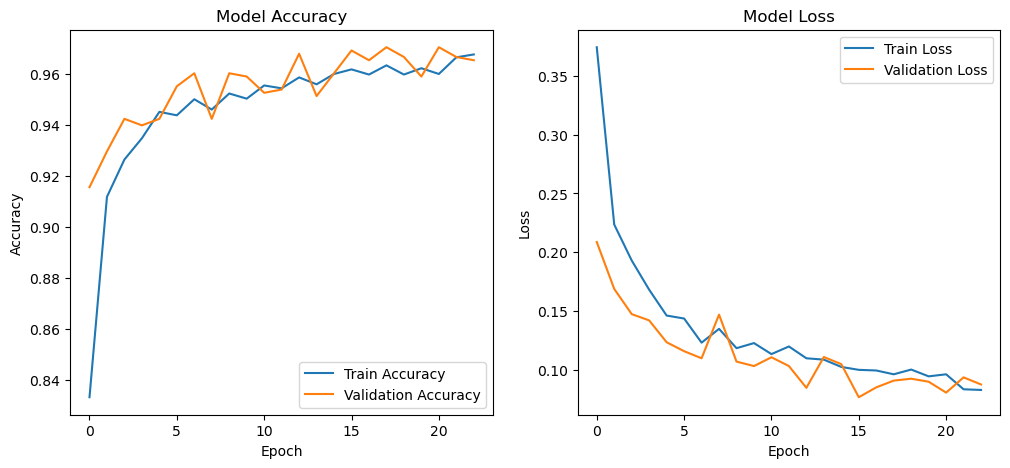

In [33]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# **Precision-Recall Curve**

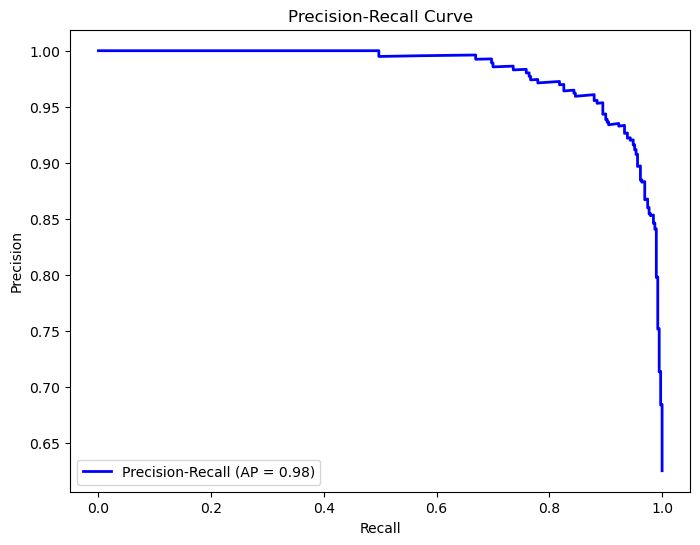

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(test_gen.classes, y_pred_probs)
avg_precision = average_precision_score(test_gen.classes, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, 
         label=f'Precision-Recall (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# **Prediction Distribution**

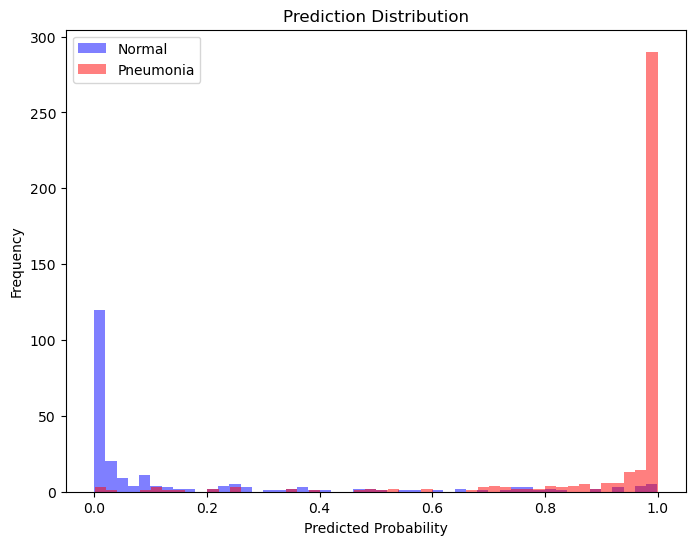

In [35]:
plt.figure(figsize=(8, 6))
plt.hist(y_pred_probs[test_gen.classes == 0], bins=50, alpha=0.5, label='Normal', color='blue')
plt.hist(y_pred_probs[test_gen.classes == 1], bins=50, alpha=0.5, label='Pneumonia', color='red')
plt.title('Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# **Saving the Model**

In [36]:
model.save('pneumonia_detection-alpha.h5')

In [37]:
# Save the class indices (important for Streamlit)
import json
with open('class_indices.json', 'w') as f:
    json.dump(train_gen.class_indices, f)

In [38]:
import sys
import tensorflow as tf
import keras

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

# Additional environment information
print("\nAdditional Info:")
print("TensorFlow path:", tf.__file__)
print("Keras path:", keras.__file__)
print("Python executable:", sys.executable)

# Check if GPU is available
print("\nGPU Information:")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
if tf.config.list_physical_devices('GPU'):
    print("GPU Device Name:", tf.test.gpu_device_name())
    print("CUDA Version:", tf.sysconfig.get_build_info()["cuda_version"])
    print("cuDNN Version:", tf.sysconfig.get_build_info()["cudnn_version"])
else:
    print("No GPU detected")

Python version: 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
TensorFlow version: 2.12.0
Keras version: 2.12.0

Additional Info:
TensorFlow path: /opt/conda/lib/python3.10/site-packages/tensorflow/__init__.py
Keras path: /opt/conda/lib/python3.10/site-packages/keras/__init__.py
Python executable: /opt/conda/bin/python3.10

GPU Information:
Num GPUs Available: 2
GPU Device Name: /device:GPU:0
CUDA Version: 11.8
cuDNN Version: 8
